# Machine Learning Lab 2
## From Raw Data to ML-Ready Data — Data Cleaning & Exploratory Data Analysis

**Student Name:** Shiza Shaikh  
**Course:** BS Computer Science  
**Lab:** Lab 2  
**GitHub Repository:** [lab2-churn-eda](https://github.com/shizashaikh55/lab2-churn-eda)

> This notebook follows Parts 1–12 of the lab manual. The purpose is to understand, clean, and explore the Telco Customer Churn dataset before any ML model is trained.


# Setup and Dataset Loading

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



# Change the filename if your CSV has a different name
file_name = 'WA_Fn-UseC_-Telco-Customer-Churn.csv'
df = pd.read_csv(file_name)

print("Dataset loaded successfully!")
df.head()

Dataset loaded successfully!


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# Part 1 — The Business Problem

## Task 1
The telecommunications company is losing customers who leave its services for competitors. The goal is to understand which customers are likely to churn so that the company can take action before they leave. The likely target variable is **Churn**, which indicates whether a customer leaves or stays.

## Task 2 — Expected Predictors

| Column | Expected usefulness | Reason |
|---|---|---|
| tenure | Useful | The length of time a customer has stayed may affect the chance of leaving. |
| Contract | Useful | Customers with different contract types may have different churn behavior. |
| MonthlyCharges | Useful | Higher monthly charges may influence a customer's decision to leave. |
| InternetService | Useful | Service type may be related to customer satisfaction and churn. |
| PaymentMethod | Useful | Payment behavior may be associated with churn patterns. |
| customerID | Not useful | It is mainly a unique identifier and does not describe customer behavior. |
| (To verify after EDA) | Possibly less useful | Final usefulness should be decided after investigating the data. |

## Task 3 — Questions
1. Are customers with month-to-month contracts more likely to churn?
2. Do customers with higher monthly charges have a higher chance of churn?


# Part 2 — Exploring the Dataset Structure

In [5]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nDataset information:")
df.info()

Shape: (7043, 21)

Columns:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data types:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

Dataset information:
<class 'pan

In [7]:
print("First 5 rows:")
display(df.head())

print("Random 5 rows:")
display(df.sample(5, random_state=42))

print("Summary statistics:")
display(df.describe(include='all').T)

First 5 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Random 5 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
185,1024-GUALD,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,24.80,24.8,Yes
2715,0484-JPBRU,Male,0,No,No,41,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Bank transfer (automatic),25.25,996.45,No
3825,3620-EHIMZ,Female,0,Yes,Yes,52,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.35,1031.7,No
1807,6910-HADCM,Female,0,No,No,1,Yes,No,Fiber optic,No,...,Yes,No,No,No,Month-to-month,No,Electronic check,76.35,76.35,Yes
132,8587-XYZSF,Male,0,No,No,67,Yes,No,DSL,No,...,No,Yes,No,No,Two year,No,Bank transfer (automatic),50.55,3260.1,No


Summary statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
# Identify columns automatically
numerical_features = df.select_dtypes(include=['int64', 'float64', 'int32', 'float32']).columns.tolist()
categorical_features = df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

print("Number of customers:", df.shape[0])
print("Total columns:", df.shape[1])
print("Numerical features:", numerical_features)
print("Categorical features:", categorical_features)

<ipython-input-9-6ea2431fb373>:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()


Number of customers: 7043
Total columns: 21
Numerical features: ['SeniorCitizen', 'tenure', 'MonthlyCharges']
Categorical features: ['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Churn']


## Task 4 — Interpretation
Each row represents one customer. The code output above shows the exact number of customers and columns in the provided dataset. Numerical and categorical columns are listed separately based on their current data types.

## Task 5
`customerID` is expected to be an identifier rather than a predictive feature. The code below checks whether its values are unique. The data types are also reviewed to find columns whose type does not match what they represent.


In [10]:
if 'customerID' in df.columns:
    print("Unique customer IDs:", df['customerID'].nunique())
    print("Total rows:", len(df))

# Check TotalCharges specifically if it exists
if 'TotalCharges' in df.columns:
    print("\nTotalCharges data type:", df['TotalCharges'].dtype)
    print(df['TotalCharges'].head(10))

Unique customer IDs: 7043
Total rows: 7043

TotalCharges data type: str
0      29.85
1     1889.5
2     108.15
3    1840.75
4     151.65
5      820.5
6     1949.4
7      301.9
8    3046.05
9    3487.95
Name: TotalCharges, dtype: str


## Task 6 — Unique Values of 3 Categorical Columns

In [11]:
selected_cols = [c for c in ['gender', 'Partner', 'Contract'] if c in df.columns]

for col in selected_cols:
    print(f"\n{col}:")
    print(df[col].unique())
    print("Unique count:", df[col].nunique())


gender:
<StringArray>
['Female', 'Male']
Length: 2, dtype: str
Unique count: 2

Partner:
<StringArray>
['Yes', 'No']
Length: 2, dtype: str
Unique count: 2

Contract:
<StringArray>
['Month-to-month', 'One year', 'Two year']
Length: 3, dtype: str
Unique count: 3


**Interpretation:** The unique values printed above should be checked for unexpected spellings, extra spaces, inconsistent capitalization, or unexpected categories.

# Part 3 — Investigating Data Quality

In [12]:
missing_count = df.isnull().sum()
missing_percent = (df.isnull().mean() * 100).round(2)

missing_summary = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing Percentage': missing_percent
})

display(missing_summary[missing_summary['Missing Count'] > 0])

print("Fully duplicated rows:", df.duplicated().sum())

if 'customerID' in df.columns:
    print("Duplicate customer IDs:", df['customerID'].duplicated().sum())

,Missing Count,Missing Percentage


Fully duplicated rows: 0
Duplicate customer IDs: 0


In [13]:
# Inspect categorical columns for suspicious or inconsistent values
for col in categorical_features:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False).head(20))


--- customerID ---
customerID
7590-VHVEG    1
5575-GNVDE    1
3668-QPYBK    1
7795-CFOCW    1
9237-HQITU    1
9305-CDSKC    1
1452-KIOVK    1
6713-OKOMC    1
7892-POOKP    1
6388-TABGU    1
9763-GRSKD    1
7469-LKBCI    1
8091-TTVAX    1
0280-XJGEX    1
5129-JLPIS    1
3655-SNQYZ    1
8191-XWSZG    1
9959-WOFKT    1
4190-MFLUW    1
4183-MYFRB    1
Name: count, dtype: int64

--- gender ---
gender
Male      3555
Female    3488
Name: count, dtype: int64

--- Partner ---
Partner
No     3641
Yes    3402
Name: count, dtype: int64

--- Dependents ---
Dependents
No     4933
Yes    2110
Name: count, dtype: int64

--- PhoneService ---
PhoneService
Yes    6361
No      682
Name: count, dtype: int64

--- MultipleLines ---
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

--- InternetService ---
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

--- OnlineSecurity ---
OnlineSecurity

## Tasks 7–9 — Interpretation
Missing values are reported as both counts and percentages. Fully duplicated rows and duplicate customer IDs are checked separately because two identical rows are not necessarily the same issue as repeated customer identifiers. The category frequency output is used to detect suspicious values such as inconsistent spelling or formatting.

# Part 4 — Data Cleaning Decisions

In [14]:
cleaning_decisions = pd.DataFrame([
    {
        'Problem': 'Identifier column',
        'Decision': 'Remove from ML-ready dataset',
        'Method Used': 'drop(columns=[customerID])',
        'Reason': 'A unique identifier does not describe customer behavior.'
    },
    {
        'Problem': 'Incorrect numeric format, if present',
        'Decision': 'Convert to numeric',
        'Method Used': "pd.to_numeric(errors='coerce')",
        'Reason': 'A monetary value should be stored as a numeric type.'
    },
    {
        'Problem': 'Missing values',
        'Decision': 'Handle after checking amount and cause',
        'Method Used': 'drop/fill based on evidence',
        'Reason': 'The cleaning method should be justified by the amount and nature of missing data.'
    },
    {
        'Problem': 'Duplicate rows',
        'Decision': 'Remove exact duplicates if found',
        'Method Used': 'drop_duplicates()',
        'Reason': 'Repeated identical records can bias analysis.'
    }
])

display(cleaning_decisions)

,Problem,Decision,Method Used,Reason
0,Identifier column,Remove from ML-ready dataset,drop(columns=[customerID]),A unique identifier does not describe customer...
1,"Incorrect numeric format, if present",Convert to numeric,pd.to_numeric(errors='coerce'),A monetary value should be stored as a numeric...
2,Missing values,Handle after checking amount and cause,drop/fill based on evidence,The cleaning method should be justified by the...
3,Duplicate rows,Remove exact duplicates if found,drop_duplicates(),Repeated identical records can bias analysis.


In [15]:
# Create intermediate cleaned dataframe
clean_df = df.copy()

# Remove surrounding whitespace from text columns
for col in clean_df.select_dtypes(include='object').columns:
    clean_df[col] = clean_df[col].astype(str).str.strip().replace('nan', np.nan)

# Convert TotalCharges to numeric when present
if 'TotalCharges' in clean_df.columns:
    clean_df['TotalCharges'] = pd.to_numeric(clean_df['TotalCharges'], errors='coerce')

# Remove exact duplicate rows
before_duplicates = clean_df.duplicated().sum()
clean_df = clean_df.drop_duplicates()

# Handle missing values:
# Numerical columns -> median; categorical columns -> mode
for col in clean_df.columns:
    if clean_df[col].isnull().sum() > 0:
        if pd.api.types.is_numeric_dtype(clean_df[col]):
            clean_df[col] = clean_df[col].fillna(clean_df[col].median())
        else:
            mode_value = clean_df[col].mode(dropna=True)
            if not mode_value.empty:
                clean_df[col] = clean_df[col].fillna(mode_value.iloc[0])

print("Duplicates before cleaning:", before_duplicates)
print("Duplicates after cleaning:", clean_df.duplicated().sum())
print("\nMissing values after cleaning:")
print(clean_df.isnull().sum()[clean_df.isnull().sum() > 0])

<ipython-input-15-75d7529648d2>:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in clean_df.select_dtypes(include='object').columns:


Duplicates before cleaning: 0
Duplicates after cleaning: 0

Missing values after cleaning:
Series([], dtype: int64)


**Cleaning justification:** Text values are stripped to remove accidental whitespace. `TotalCharges`, if stored as text, is converted to numeric because it represents a monetary amount. Exact duplicate rows are removed. Missing values are handled using the median for numerical variables and the mode for categorical variables so that the dataset can remain usable without unnecessarily removing many customer records.

# Part 5 — Univariate EDA

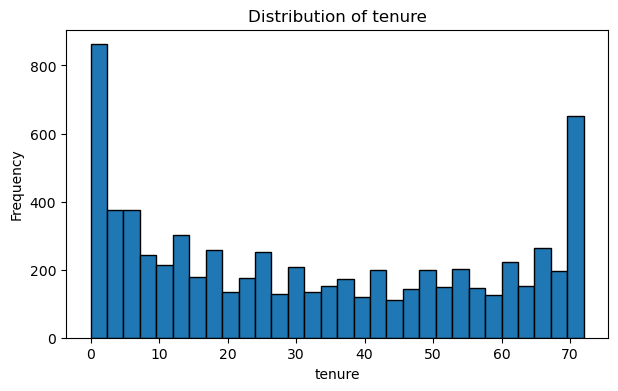

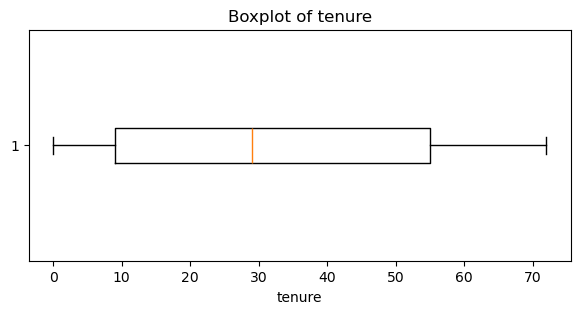

count    7043.000000
mean       32.371149
std        24.559481
min         0.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure, dtype: float64


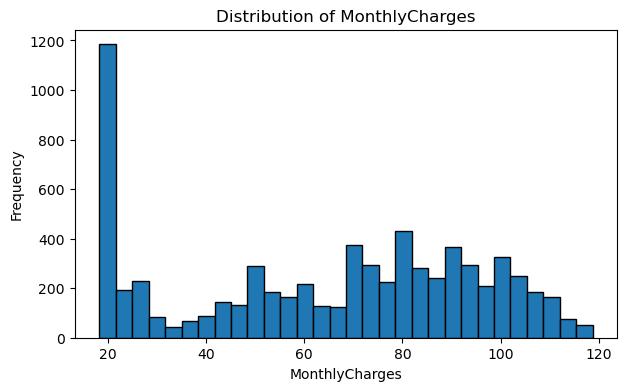

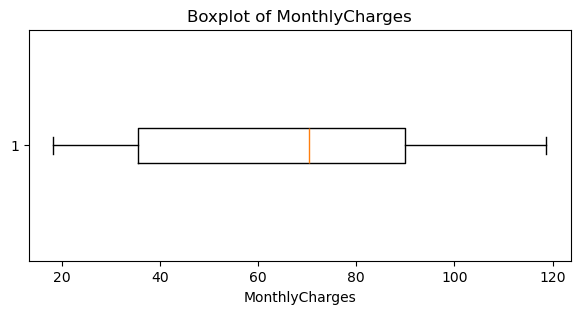

count    7043.000000
mean       64.761692
std        30.090047
min        18.250000
25%        35.500000
50%        70.350000
75%        89.850000
max       118.750000
Name: MonthlyCharges, dtype: float64


In [16]:
num_cols_to_plot = [c for c in ['tenure', 'MonthlyCharges'] if c in clean_df.columns]

for col in num_cols_to_plot:
    plt.figure(figsize=(7,4))
    plt.hist(clean_df[col].dropna(), bins=30, edgecolor='black')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

    plt.figure(figsize=(7,3))
    plt.boxplot(clean_df[col].dropna(), vert=False)
    plt.title(f'Boxplot of {col}')
    plt.xlabel(col)
    plt.show()

    print(clean_df[col].describe())

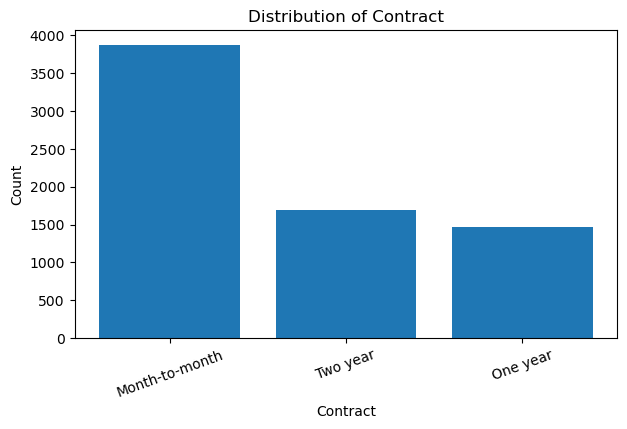


Contract counts:
Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64


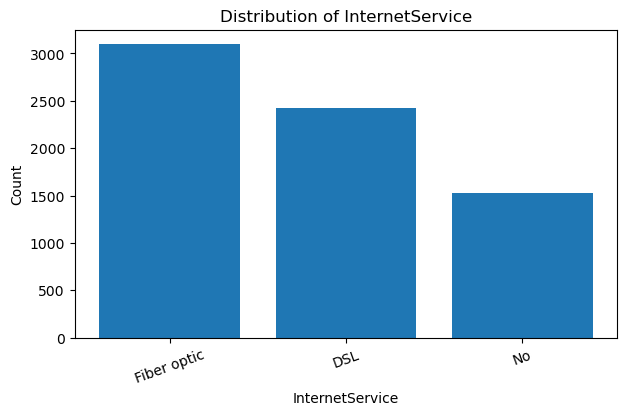


InternetService counts:
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64


In [17]:
cat_cols_to_plot = [c for c in ['Contract', 'InternetService'] if c in clean_df.columns]

for col in cat_cols_to_plot:
    counts = clean_df[col].value_counts()
    plt.figure(figsize=(7,4))
    plt.bar(counts.index.astype(str), counts.values)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=20)
    plt.show()

    print(f"\n{col} counts:")
    print(counts)

## Interpretation
For each numerical chart, use the histogram to describe where most values are concentrated and use the boxplot to identify possible outliers. For each categorical chart, describe which category is most and least common based on the displayed counts. The exact interpretation should match the output generated from the provided dataset.

# Part 6 — Target Variable Analysis

,Count,Percentage
Churn,,
No,5174,73.46
Yes,1869,26.54


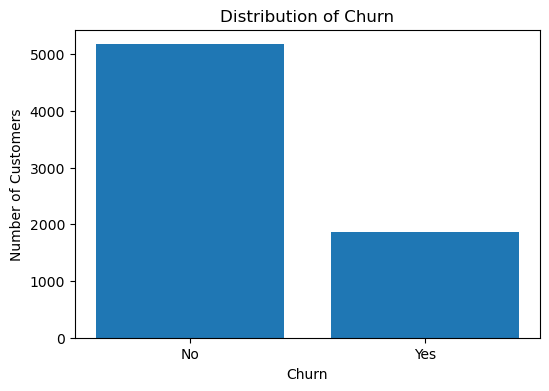

In [18]:
churn_counts = clean_df['Churn'].value_counts(dropna=False)
churn_percent = (clean_df['Churn'].value_counts(normalize=True, dropna=False) * 100).round(2)

target_summary = pd.DataFrame({
    'Count': churn_counts,
    'Percentage': churn_percent
})
display(target_summary)

plt.figure(figsize=(6,4))
plt.bar(churn_counts.index.astype(str), churn_counts.values)
plt.title('Distribution of Churn')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')
plt.show()

## Task 14–15 — Interpretation
The table above reports the number and percentage of churned and non-churned customers. If one class is much larger than the other, the target is imbalanced. Class imbalance can matter because a classification model may appear accurate by predicting the majority class more often while performing poorly on the smaller class.

# Part 7 — Bivariate Analysis: Features vs. Churn


Churn rate by Contract:


Churn,No,Yes
Contract,,
Month-to-month,57.29,42.71
One year,88.73,11.27
Two year,97.17,2.83


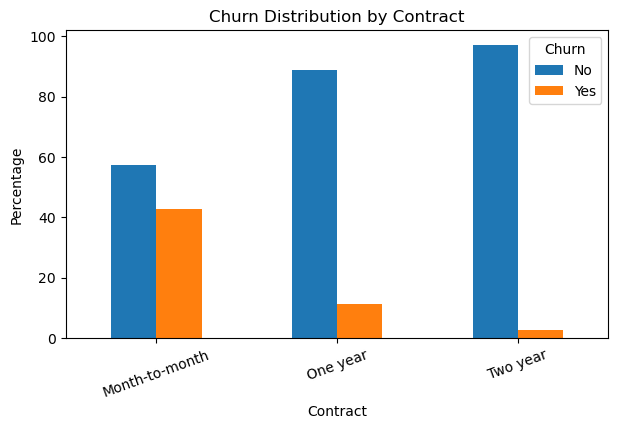


Churn rate by InternetService:


Churn,No,Yes
InternetService,,
DSL,81.04,18.96
Fiber optic,58.11,41.89
No,92.60,7.40


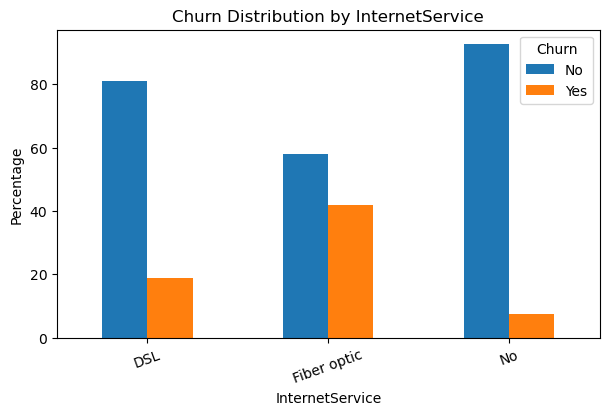

In [20]:
# Categorical features vs Churn
for col in [c for c in ['Contract', 'InternetService'] if c in clean_df.columns]:
    print(f"\nChurn rate by {col}:")
    result = pd.crosstab(clean_df[col], clean_df['Churn'], normalize='index') * 100
    display(result.round(2))

    result.plot(kind='bar', figsize=(7,4))
    plt.title(f'Churn Distribution by {col}')
    plt.ylabel('Percentage')
    plt.xticks(rotation=20)
    plt.show()

In [7]:
import matplotlib.pyplot as plt

# Numerical features vs Churn (Pure Matplotlib)
for col in [c for c in ['tenure', 'MonthlyCharges'] if c in clean_df.columns]:
    plt.figure(figsize=(7, 4))
    
    # Separate data by Churn categories
    churn_no = clean_df[clean_df['Churn'] == 'No'][col].dropna()
    churn_yes = clean_df[clean_df['Churn'] == 'Yes'][col].dropna()
    
    # Create Boxplot
    plt.boxplot([churn_no, churn_yes], labels=['No', 'Yes'])
    plt.title(f'{col} by Churn')
    plt.xlabel('Churn')
    plt.ylabel(col)
    plt.show()

    # Print summary statistics
    print(f"\nAverage {col} by Churn:")
    print(clean_df.groupby('Churn')[col].agg(['mean', 'median', 'count']).round(2))



<class 'NameError'>: name 'clean_df' is not defined

## Observation / Evidence / Possible Explanation
Use the output above for each feature:
- **Observation:** State the visible pattern.
- **Evidence:** Mention the percentage, mean, or median shown in the table.
- **Possible Explanation:** Give a reasonable business explanation without claiming causation.


# Part 8 — Correlation & Feature Relationships

In [22]:
numeric_df = clean_df.select_dtypes(include=np.number)
corr_matrix = numeric_df.corr()

display(corr_matrix.round(2))

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

# Show strongest correlations
corr_pairs = (
    corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    .stack()
    .sort_values(key=lambda x: x.abs(), ascending=False)
)
print("Strongest correlations:")
print(corr_pairs.head(10))

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
SeniorCitizen,1.00,0.02,0.22,0.10
tenure,0.02,1.00,0.25,0.83
MonthlyCharges,0.22,0.25,1.00,0.65
TotalCharges,0.10,0.83,0.65,1.00


<Figure size 800x600 with 0 Axes>

<class 'NameError'>: name 'sns' is not defined

## Tasks 18–19 — Interpretation
The correlation matrix and ranked output show which numerical feature pairs have the strongest relationships. Correlation does not imply causation: two variables can move together without one directly causing the other. Highly correlated features may contain overlapping information and could create redundancy in some future models.

# Part 9 — Data Leakage Awareness

## Task 20
Potential suspects should include:
- **customerID:** This is an identifier, not useful customer behavior information.
- Any column that would only be known after the customer has already churned should be treated as possible leakage.

Based on the standard Telco columns, `customerID` is removed as an identifier. The remaining columns should be reviewed to confirm that they describe information available before predicting churn.

## Task 21
If a leakage column is included, the model could use information that would not actually be available at prediction time. This can make the model appear artificially accurate during evaluation but perform poorly in real-world use.


# Part 10 — ML-Readiness Checklist

In [23]:
readiness_rows = []

for col in clean_df.columns:
    if col == 'Churn':
        col_type = 'Categorical'
        role = 'Target'
        action = 'Keep'
        reason = 'This is the variable to be predicted.'
    elif col == 'customerID':
        col_type = 'Identifier'
        role = 'Identifier'
        action = 'Remove'
        reason = 'Unique identifier, not a behavioral predictor.'
    elif pd.api.types.is_numeric_dtype(clean_df[col]):
        col_type = 'Numerical'
        role = 'Feature'
        action = 'Keep'
        reason = 'Potential predictive numerical feature.'
    else:
        col_type = 'Categorical'
        role = 'Feature'
        action = 'Keep'
        reason = 'Potential predictive categorical feature.'

    readiness_rows.append([col, col_type, role, action, reason])

ml_readiness = pd.DataFrame(
    readiness_rows,
    columns=['Column', 'Type', 'Role', 'Action', 'Reason']
)

display(ml_readiness)

,Column,Type,Role,Action,Reason
0,customerID,Identifier,Identifier,Remove,"Unique identifier, not a behavioral predictor."
1,gender,Categorical,Feature,Keep,Potential predictive categorical feature.
2,SeniorCitizen,Numerical,Feature,Keep,Potential predictive numerical feature.
3,Partner,Categorical,Feature,Keep,Potential predictive categorical feature.
4,Dependents,Categorical,Feature,Keep,Potential predictive categorical feature.
5,tenure,Numerical,Feature,Keep,Potential predictive numerical feature.
6,PhoneService,Categorical,Feature,Keep,Potential predictive categorical feature.
7,MultipleLines,Categorical,Feature,Keep,Potential predictive categorical feature.
8,InternetService,Categorical,Feature,Keep,Potential predictive categorical feature.
9,OnlineSecurity,Categorical,Feature,Keep,Potential predictive categorical feature.


# Part 11 — Building the Clean Dataset

In [24]:
# Remove identifier column for final ML-ready dataset
final_columns_to_drop = [c for c in ['customerID'] if c in clean_df.columns]
clean_df = clean_df.drop(columns=final_columns_to_drop)

# Final checks
print("Final shape:", clean_df.shape)
print("\nMissing values:", clean_df.isnull().sum().sum())
print("Duplicate rows:", clean_df.duplicated().sum())

print("\nFinal dataframe information:")
clean_df.info()

# Save cleaned dataset
clean_df.to_csv('clean_churn.csv', index=False)
print("\nSaved successfully as clean_churn.csv")

Final shape: (7043, 20)

Missing values: 0
Duplicate rows: 22

Final dataframe information:
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  Paperles

# Part 12 — Five Key Findings & Final Reflection

In [25]:
# Helpful summaries for writing evidence-based findings
print("1. Churn distribution:")
display(clean_df['Churn'].value_counts(normalize=True).mul(100).round(2))

for col in ['Contract', 'InternetService', 'PaymentMethod']:
    if col in clean_df.columns:
        print(f"\nChurn rates by {col}:")
        display((pd.crosstab(clean_df[col], clean_df['Churn'], normalize='index') * 100).round(2))

for col in ['tenure', 'MonthlyCharges']:
    if col in clean_df.columns:
        print(f"\n{col} by Churn:")
        display(clean_df.groupby('Churn')[col].mean().round(2))

1. Churn distribution:


Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


Churn rates by Contract:


Churn,No,Yes
Contract,,
Month-to-month,57.29,42.71
One year,88.73,11.27
Two year,97.17,2.83



Churn rates by InternetService:


...

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.29,16.71
Credit card (automatic),84.76,15.24
Electronic check,54.71,45.29
Mailed check,80.89,19.11



tenure by Churn:


Churn
No     37.57
Yes    17.98
Name: tenure, dtype: float64


MonthlyCharges by Churn:


Churn
No     61.27
Yes    74.44
Name: MonthlyCharges, dtype: float64

## 
Five Key Findings

### Finding 1
**Observation:** Use the churn distribution shown above.  
**Evidence:** Report the exact percentages.  
**Interpretation:** Explain whether churn is a minority or majority outcome.

### Finding 2
**Observation:** Identify the contract category with the highest churn rate.  
**Evidence:** Use the percentage from the Contract table.  
**Interpretation:** Explain why contract length may be associated with customer retention.

### Finding 3
**Observation:** Compare average tenure between churned and non-churned customers.  
**Evidence:** Use the group mean output.  
**Interpretation:** Explain what this suggests about newer versus long-term customers.

### Finding 4
**Observation:** Compare MonthlyCharges between churn groups.  
**Evidence:** Use the group mean output and boxplot.  
**Interpretation:** Explain the possible relationship between charges and churn.

### Finding 5
**Observation:** Select another meaningful pattern from InternetService or PaymentMethod.  
**Evidence:** Report the exact churn rate.  
**Interpretation:** Explain why this feature may be useful for future prediction.

## Final Reflection

**1. What was the most important data-quality issue you found?**  
The most important issue was the data-quality problem identified during Part 3, especially any incorrect data type or missing values found in the dataset. It was important because incorrect values could affect later analysis and ML modeling.

**2. What was the most interesting pattern you discovered?**  
The most interesting pattern should be selected from the churn comparisons above, especially the feature showing the clearest difference between churned and non-churned customers.

**3. Which feature seems most useful for predicting churn?**  
Based on the bivariate analysis, choose the feature with the clearest difference in churn rates or numerical distribution and support the answer with evidence.

**4. Which feature should probably not be used, and why?**  
`customerID` should not be used because it is only an identifier and does not represent meaningful customer behavior.

**5. What preprocessing will be required before ML modeling?**  
Categorical variables will need encoding, numerical features may need scaling depending on the model, and the target variable may need conversion into a machine-readable format.

**6. What would you do next if you had another 3 hours?**  
I would investigate more feature relationships, study customer subgroups, test possible feature-engineering ideas, and further examine patterns that could improve churn prediction in the next lab.

https://github.com/shizashaikh55/lab2-churn-eda


In [1]:
import os

# Check if clean_churn.csv exists in the current folder
if os.path.exists('clean_churn.csv'):
    print("SUCCESS: 'clean_churn.csv' ban chuki hai aur folder mein majood hai!")
else:
    print("ATTENTION: 'clean_churn.csv' nahi mili. Part 11 ka export code dobara run karein.")

SUCCESS: 'clean_churn.csv' ban chuki hai aur folder mein majood hai!
